##ЛР3. Задача классификации

[12 баллов]

## О формате сдачи (все ЛР)

🔷 **<font color='plum'>При решении используйте данный шаблон</font>**

    ✅ Можно добавлять новые ячейки любых типов
    ❌ Не нужно удалять текстовые ячейки c разметкой частей ноутбука и формулировками заданий


🔷 **<font color='plum'>При оценивании задач учитывается код</font>**

    ✅ Задания, в которых необходим код, могут помечаться фразами "Your code here"/"Ваш код" и аналогичными
    ❌ Ответы на вопросы без сопутствующего кода оцениваются в 0 баллов
    ❌ Наличие работоспособного кода в ноутбуке, если на сказано иного, обязательно

🔷 **<font color='plum'>При оценивании задач учитываются выводы</font>**

    ✅ Задания, в которых необходимы выводы, могут помечаться фразами "Вывод"/"Ответ на вопрос"/"Ваш текст" и аналогичными
    ✅ Выводы подразумевают текстовый (письменный, не устный) ответ (можно писать markdown, latex).
    ✅ Сопутствующие изображения, графики, таблички - приветствуются!
    ❌ При отсутствии выводов задание не засчитается на полный балл

🔷 **<font color='plum'>Устная защита</font>**

    ❌❌❌ Если не пройдена устная защита по ЛР, то баллы не начисляются вовсе
    (вопросы устной защиты охватывают лекционный материал и практический материал по заданиям ЛР, список вопросов не публикуется)

## Этапы

<font color='DarkOrange'>**Задание 1 [баллов: 2]:**</font>

Выберите датасет и задачу для него (классификация) - с Kaggle или UCI Machine Learning Repository (https://archive.ics.uci.edu/datasets).
Важно: используйте более новые датасеты, кол-во объектов не менее 100.
Лучше воспользоваться датасетом из предыдущих ЛР.

Выберите (или сгенерите сами) признак, который будет целевым для бинарной классификации.

Используйте LogisticRegression из sklearn. Задайте несколько параметров метода самостоятельно, поясните их назначение и причину выбора конкретных значений.
Используйте несколько метрик, чтоб оценить результаты бинарной классификации (метрики, доступные в sklearn).

<font color='DarkOrange'>**Задание 2 [баллов: 2]:**</font>

Выполните бинарную классификацию аналогично тпредыдущему пункту с использованием SVM (SVC из sklearn, используйте kernel=‘linear’, сами подберите параметр регуляризации С и ответьте на вопрос, может ли/как может SVM учесть несбалансированность классов)


<font color='DarkOrange'>**Задание 3 [баллов: 6]:**</font>

1. Многоклассовая классификация. Дайте определения для подходов: микро, макро, взвешенный, пообъктный. Выполните расчёты вручную для слайда 43 (на примере любых 3 промежуточных AUC ROC, поясните, как из промежуточных характеристик получаются 4 финальных). В рамках детализации ОЦИФРУЙТЕ ROC: в Excel, отрисуйте линиями в Word или отрисуйте отдельными отрезками Python-кодом (не используйте готовые функции для ROC).
[баллов: 2]

2. Для одного из кейсов (одного класса) введите три порога бинаризации так, чтоб получились различные accuracy, recall, precision. Вычислите эти метрики вручную и сопроводите визуализацией расчёта для recall и precision (см пример из лекции с окружностями разных цветов и радиусов). По трём парам (precision, recall) постройте эскиз PR-кривой. [баллов: 2]

3. Сделайте выводы по результатам расчётом AUC ROC для многоклассовой классификации (какой вариант лучше, почему, объясните падение AUC ROC при переходе к многоклассовым). [баллов: 1]

4. В каких кейсах/доменах следует применять те или иные варианты? Запишите выводы. [баллов: 1]

<font color='DarkOrange'>**Задание 4 [баллов: 2]:**</font>

Исследуйте вопрос выбросов/новизны для данных в вашем датасете с использованием OneClassSVM (дайте краткую теоретическую характеристику, используйте готовые решения для получения результатов, сделайте выводы)

Материалы:
1) https://scikit-learn.ru/stable/modules/outlier_detection.html,
2) https://alexanderdyakonov.wordpress.com/, Поиск аномалий

# Задание 1

In [ ]:
mport pandas as pd
import numpy as np

raw = pd.read_csv("Exam_Score_Prediction.csv")

raw.head()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


In [2]:
raw["passed"] = (raw["exam_score"] >= 60).astype(int)

print(raw["passed"].value_counts())
print(raw["passed"].value_counts(normalize=True))

passed
1    11047
0     8953
Name: count, dtype: int64
passed
1    0.55235
0    0.44765
Name: proportion, dtype: float64


In [ ]:
raw_trunc = raw.drop(columns=["student_id", "age", "gender", "course", "internet_access", "sleep_hours", "exam_difficulty"])

y = raw_trunc["passed"]
X = raw_trunc.drop(columns=["exam_score", "passed"])

In [4]:
numeric_columns = X.select_dtypes(include=["number"]).columns.tolist()
categorical_columns = X.select_dtypes(exclude=["number"]).columns.tolist()

In [5]:
import numpy as np

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# class IQRClipper(BaseEstimator, TransformerMixin):
#     def __init__(self, k=1.5):
#         self.k = k

#     def fit(self, X, y):
#         X = np.asarray(X, dtype=float)
#         q1 = np.nanpercentile(X, 25, axis=0)
#         q3 = np.nanpercentile(X, 75, axis=0)
#         iqr = q3 - q1
#         self.lower = q1 - self.k * iqr
#         self.upper = q3 + self.k * iqr
#         return self

#     def transform(self, X):
#         X = np.asarray(X, dtype=float)
#         return np.clip(X, self.lower, self.upper)

In [10]:
num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("clipper", IQRClipper(k=1.5)),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, numeric_columns),
        ("cat", cat_pipeline, categorical_columns)
    ]
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("classifier", LogisticRegression(
        C=1.0,
        solver="lbfgs",
        max_iter=1000,
        random_state=42
    ))
])

## Cross validation

In [13]:
from sklearn.model_selection import StratifiedKFold, cross_validate
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = cross_validate(
    model,
    X,
    y,
    cv=skf,
    scoring=scoring,
    n_jobs=-1
)

print("\nKFold (5) results:")

for metric in scoring.keys():
    scores = cv_results["test_" + metric]
    print(f"{metric:10s}: {scores.mean():.3f} ± {scores.std():.3f}")


KFold (5) results:
accuracy  : 0.845 ± 0.006
precision : 0.858 ± 0.007
recall    : 0.862 ± 0.005
f1        : 0.860 ± 0.005
roc_auc   : 0.926 ± 0.004


## Задание 2

In [18]:
from sklearn.svm import SVC

svm_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("classifier", SVC(kernel="linear", random_state=42))
])

In [ ]:
from sklearn.model_selection import GridSearchCV

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    estimator=svm_model,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

grid.fit(X, y)
print("Best C:", grid.best_params_["classifier__C"])
print("Best CV F1:", grid.best_score_)

best_svm = grid.best_estimator_

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_res = cross_validate(
    best_svm,
    X, y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("\nSVM (linear) StratifiedKFold (5) results:")
for m in scoring:
    scores = cv_res["test_" + m]
    print(f"{m:10s}: {scores.mean():.3f} ± {scores.std():.3f}")

Best C: 0.1
Best CV F1: 0.8603508796234781

SVM (linear) StratifiedKFold (5) results:
accuracy  : 0.845 ± 0.006
precision : 0.858 ± 0.007
recall    : 0.863 ± 0.007
f1        : 0.860 ± 0.006
roc_auc   : 0.926 ± 0.004


## Дисбаланс классов

Ошибка минимизируется на всех классах одинаково, поэтому на доминируеющем классе модель будет работать лучше. Чтобы этого избежать, нужно
увеличить штраф модели за ошибки на редком классе.

в sklearn есть такая штука: `class_weight='balanced'`

Он автоматически увеличивает штраф за ошибки на редком классе.

```python
SVC(kernel="linear", C=..., class_weight="balanced", random_state=42)
```

# Задание 3

## Дайте определения для подходов: микро, макро, взвешенный, пообъктный.

Тут про усреднение метрик в многоклассовой классификации.

Напоминаю F1 - попытка выразить precision и recall одним числом. Реализуется с помощью гармонического среднего:

$F_1 = \frac{2 \cdot Precision \cdot Recall}{Precision + Recall}$

### Macro

Макро усреднение заключается в подсчете F1 для каждого класса и нахождения среднего арифметического:

$F1_{\text{macro}} = \frac{1}{K} \sum_{k=1}^{K} F1_k$

### Weighted

Учитываем веса для каждого класса:

$F1_{\text{weighted}} = \sum_{k=1}^{K} \frac{n_k}{N} F1_k$, \
$n_{k}$ - количество объектов класса k, $N$ - общее количество объектов

### Micro

Считаем precision и recall сразу для всех классов:

$
Precision_{\text{micro}} = 
\frac{\sum_{k=1}^{K} TP_k}
{\sum_{k=1}^{K} TP_k + \sum_{k=1}^{K} FP_k}
$

$
Recall_{\text{micro}} = 
\frac{\sum_{k=1}^{K} TP_k}
{\sum_{k=1}^{K} TP_k + \sum_{k=1}^{K} FN_k}
$

### Samples average

Пообъектный. Используется в том случае, если для каждого объекта нужно предсказывать категориальный вектор.

Тогда считаем все то же самое (recall, precision, f1), но для каждого объекта, а потом усредняем:

$F1_{\text{samples}} = \frac{1}{N} \sum_{i=1}^{N} F1_i$


## Выполните расчёты вручную для слайда 43 (на примере любых 3 промежуточных AUC ROC, поясните, как из промежуточных характеристик получаются 4 финальных). 

In [20]:
import numpy as np

# "True" data
y_true = np.array([
    [1, 1, 0],  # x1
    [0, 1, 1],  # x2
    [0, 1, 0],  # x3
    [1, 0, 0],  # x4
])

# Model answers
y_scores = np.array([
    [0.7, 0.6, 0.5],
    [0.3, 0.4, 0.6],
    [0.5, 0.9, 0.2],
    [0.4, 0.5, 0.1],
])


def compute_roc_points(y_true_class, y_scores_class, thresholds):
    roc_points = []

    for thresh in thresholds:
        y_pred = (y_scores_class >= thresh).astype(int)

        TP = np.sum((y_true_class == 1) & (y_pred == 1))
        FP = np.sum((y_true_class == 0) & (y_pred == 1))
        TN = np.sum((y_true_class == 0) & (y_pred == 0))
        FN = np.sum((y_true_class == 1) & (y_pred == 0))

        TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
        FPR = FP / (FP + TN) if (FP + TN) > 0 else 0

        roc_points.append((thresh, FPR, TPR))

    return roc_points

In [29]:
thresholds = [0.6, 0.5, 0.3, 0.2, 0.1]

for class_idx in range(3):
    print(f"\nClass {class_idx+1}")
    
    y_true_class = y_true[:, class_idx]
    y_scores_class = y_scores[:, class_idx]

    roc_points = compute_roc_points(
        y_true_class,
        y_scores_class,
        thresholds
    )

    for thresh, fpr, tpr in roc_points:
        print(f"Threshold={thresh:.1f} | FPR={fpr:.3f} | TPR={tpr:.3f}")


Class 1
Threshold=0.6 | FPR=0.000 | TPR=0.500
Threshold=0.5 | FPR=0.500 | TPR=0.500
Threshold=0.3 | FPR=1.000 | TPR=1.000
Threshold=0.2 | FPR=1.000 | TPR=1.000
Threshold=0.1 | FPR=1.000 | TPR=1.000

Class 2
Threshold=0.6 | FPR=0.000 | TPR=0.667
Threshold=0.5 | FPR=1.000 | TPR=0.667
Threshold=0.3 | FPR=1.000 | TPR=1.000
Threshold=0.2 | FPR=1.000 | TPR=1.000
Threshold=0.1 | FPR=1.000 | TPR=1.000

Class 3
Threshold=0.6 | FPR=0.000 | TPR=1.000
Threshold=0.5 | FPR=0.333 | TPR=1.000
Threshold=0.3 | FPR=0.333 | TPR=1.000
Threshold=0.2 | FPR=0.667 | TPR=1.000
Threshold=0.1 | FPR=1.000 | TPR=1.000


In [30]:
def compute_auc(roc_points):
    auc = 0
    for i in range(1, len(roc_points)):
        x1, y1 = roc_points[i - 1][1], roc_points[i - 1][2]
        x2, y2 = roc_points[i][1], roc_points[i][2]
        auc += (x2 - x1) * (y1 + y2) / 2
    return auc

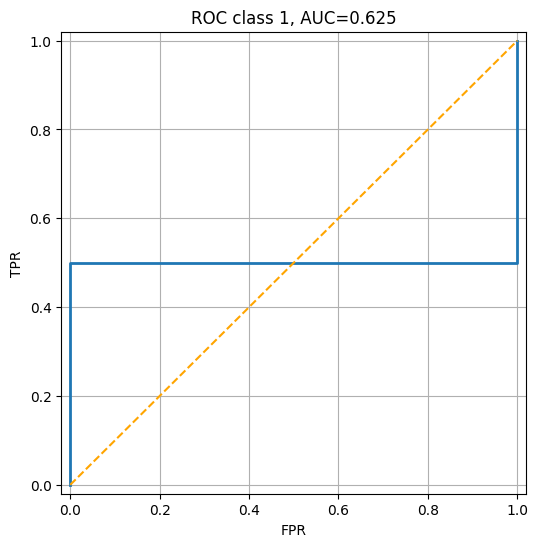

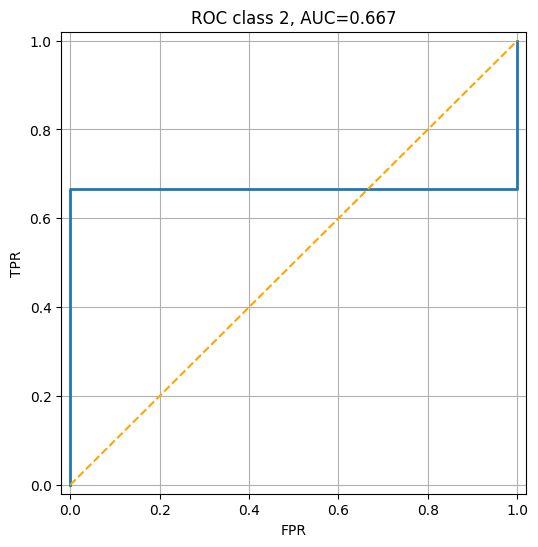

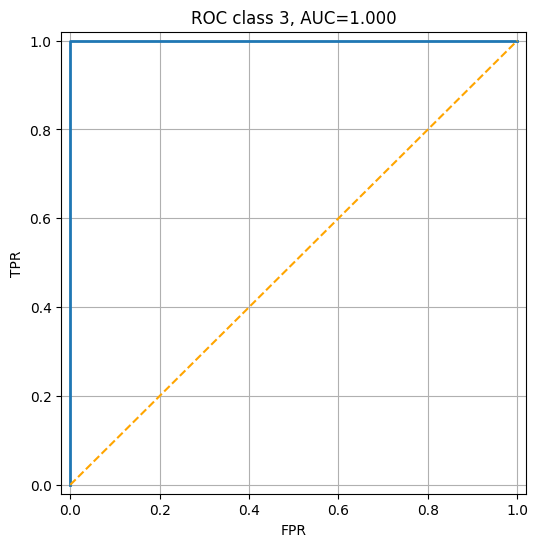

In [ ]:
def plot_roc_for_all_classes(y_true, y_scores, thresholds):
    
    for class_idx in range(y_true.shape[1]):
        
        y_true_class = y_true[:, class_idx]
        y_scores_class = y_scores[:, class_idx]
        
        roc_points = compute_roc_points(
            y_true_class,
            y_scores_class,
            thresholds
        )

        roc_points_extended = [(None, 0, 0)] + roc_points + [(None, 1, 1)]
        roc_points_extended.sort(key=lambda x: x[1])

        auc = compute_auc(roc_points_extended)
        fpr = [p[1] for p in roc_points_extended]
        tpr = [p[2] for p in roc_points_extended]

        plt.figure(figsize=(6,6))
        plt.step(fpr, tpr, where='post', linewidth=2)
        plt.plot([0,1], [0,1], '--', color='orange')

        plt.xlabel("FPR")
        plt.ylabel("TPR")
        plt.title(f"ROC class {class_idx+1}, AUC={auc:.3f}")
        plt.grid(True)
        plt.xlim(-0.02, 1.02)
        plt.ylim(-0.02, 1.02)
        plt.show()

plot_roc_for_all_classes(y_true, y_scores, thresholds)

In [50]:
def compute_acc_rec_prec(y_true_class, y_scores_class, thresholds):
    acc_rec_prec = []

    for thresh in thresholds:
        y_pred = (y_scores_class >= thresh).astype(int)

        TP = np.sum((y_true_class == 1) & (y_pred == 1))
        FP = np.sum((y_true_class == 0) & (y_pred == 1))
        TN = np.sum((y_true_class == 0) & (y_pred == 0))
        FN = np.sum((y_true_class == 1) & (y_pred == 0))

        accuracy = (TP + TN) / (TP + TN + FP + FN)
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0

        print(f"thresh: {thresh}, TP: {TP}, FP: {FP}, TN: {TN}, FN: {FN},")

        acc_rec_prec.append((thresh, accuracy, recall, precision))

    return acc_rec_prec

thresholds = [0.6, 0.4, 0.1]

class_idx = 0 # class 1

print(f"\nClass {class_idx+1}")

y_true_class = y_true[:, class_idx]
y_scores_class = y_scores[:, class_idx]

roc_points = compute_acc_rec_prec(
    y_true_class,
    y_scores_class,
    thresholds
)

for thresh, accuracy, recall, precision in roc_points:
    print(f"Threshold={thresh:.1f} | accuracy={accuracy:.3f} | recall={recall:.3f} | precision={precision:.3f}")


Class 1
thresh: 0.7, TP: 1, FP: 0, TN: 2, FN: 1,
thresh: 0.4, TP: 2, FP: 1, TN: 1, FN: 0,
thresh: 0.1, TP: 2, FP: 2, TN: 0, FN: 0,
Threshold=0.7 | accuracy=0.750 | recall=0.500 | precision=1.000
Threshold=0.4 | accuracy=0.750 | recall=1.000 | precision=0.667
Threshold=0.1 | accuracy=0.500 | recall=1.000 | precision=0.500


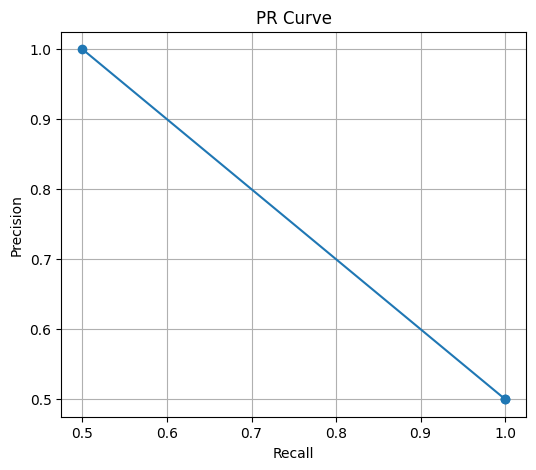

In [47]:
import matplotlib.pyplot as plt

recalls = [0.5, 1.0, 1.0]
precisions = [1.0, 0.5, 0.5]

plt.figure(figsize=(6,5))
plt.plot(recalls, precisions, marker='o')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve")
plt.grid(True)
plt.show()

## Threshold = 0.6
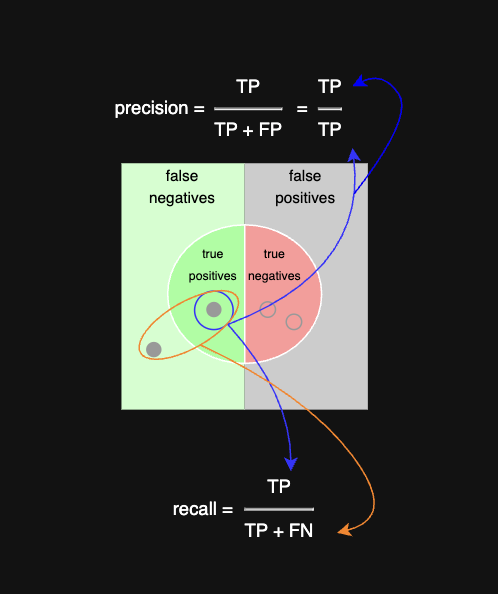

## Threshold = 0.4
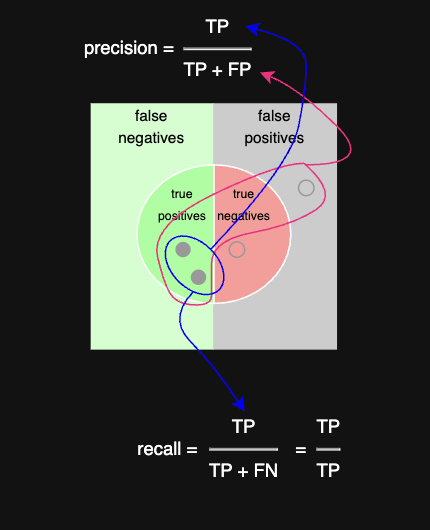

## Threshold = 0.1
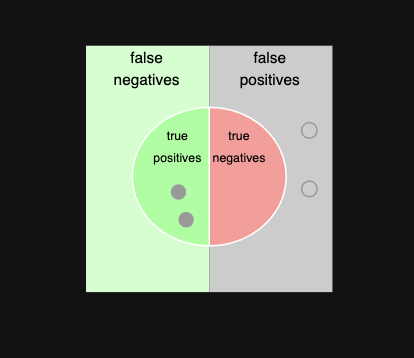

## Выводы по результатам расчётом AUC ROC для многоклассовой классификации

AUC ROC для многоклассовой классификации чаще всего считают по схеме «один класс против всех остальных» (one-vs-rest). Для каждого класса строят ROC и AUC, а потом усредняют.

### Падение AUC ROC при переходе к многоклассовым

В бинарном случае вы сравниваете положительные с явно непохожими отрицательными. В мультиклассе отрицательные для класса k — это все другие классы, некоторые из которых очень похожи на k. Поэтому модель чаще путает, и ранжирование становится хуже и AUC падает.

### Какой вариант лучше

Нет универсального лучшего варианта, вссе зависит от задачи:
- Нужна справедливость между классами - macro.
- Нужно нормировать классы по их частоте - weighted. \
и тд.

## В каких кейсах/доменах следует применять те или иные варианты

### Macro

Применяется, когда все классы равнозначны, независимо от их частоты.

Пример: Медицина - есть редкая болезнь (1%) и частая (50%). Если модель идеально предсказывает частую, но игнорирует редкую —
Macro резко упадёт, потому что редкая болезнь считается так же важной.

### Weighted

Используется при дисбалансе классов, когда важно учитывать реальное распределение данных.

Пример: поведенческая аналитика. Большинство пользователей - обычные, а маленький процент - аномальные. Если в данном случае нужна общая статистика, то логично, что ориентироваться надо на большинство.

### Micro

Применяется, когда важна общая производительность всей системы, а не качество по отдельным классам.

Пример: Большая система распознавания изображений на 100 классов. Нас не интересует каждый класс отдельно. Имеет значение только то, сколько всего объектов правильно классифицировано.

### Samples (пообъектный)

Используется, если каждый объект может принадлежать нескольким классам одновременно.

Ну тут просто про другую структуру. Нужно везде, где необходимо предсказывать несколько меток. Например снова медицина: если нужно корректно предсказывать комбинацию болезней для пациента.

In [ ]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.svm import OneClassSVM

raw = pd.read_csv("Exam_Score_Prediction.csv")
raw = raw.drop(columns=["student_id"])


X = raw.copy()

numeric_columns = X.select_dtypes(include=["number"]).columns.tolist()
categorical_columns = X.select_dtypes(exclude=["number"]).columns.tolist()

num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, numeric_columns),
        ("cat", cat_pipeline, categorical_columns)
    ]
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("ocsvm", OneClassSVM(
        kernel="rbf",
        gamma="scale",
        nu=0.05
    ))
])

model.fit(X)
pred = model.predict(X)

raw["anomaly"] = pred
print(raw["anomaly"].value_counts())

anomaly
 1    18996
-1     1004
Name: count, dtype: int64


## One-Class SVM

One-Class SVM — алгоритм поиска аномалий.

Предполагается, что обучающая выборка состоит преимущественно из нормальных объектов, и модель ищет компактную область высокой плотности данных. То есть он строит границу вокруг плотной области распределения, а объекты оказывшиеся вне ее считаются аномалиями.
Параметр nu определяет допустимую долю аномалий.

### Результаты

В датасете выявлено 1004 аномальных наблюдений (~5% выборки).

Они представляют собой нетипичные комбинации признаков. Возможные причины: экстремальные значения баллов, часов сна, посещаемости.